#### Imports

In [1]:
!export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

In [2]:
import matplotlib.pyplot as plt

In [3]:
import random
import json
import copy
import time
import math
from collections import Counter
from pycocotools.coco import COCO
import kagglehub

In [4]:
import spacy

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torchvision import datasets
from torch.utils.data import random_split
from torch.utils.data import DataLoader, Dataset
from torch.utils.tensorboard import SummaryWriter
from torch.optim.lr_scheduler import ReduceLROnPlateau

#### Loading the dataset

In [7]:
# path = kagglehub.dataset_download("awsaf49/coco-2017-dataset")

# print("Path to dataset files:", path)

In [8]:
# path = kagglehub.dataset_download("rabbabansh/ms-coco-2014")

# print("Path to dataset files:", path)

#### Transforming and splitting the dataset

In [9]:
image_size = 256
batch_size = 64

In [10]:
nlp = spacy.load("en_core_web_sm")
def preprocess_caption(caption, max_length=100):
  lowered_caption = caption.lower()

  tokenized_caption = [token.text for token in nlp.tokenizer(lowered_caption)]

  trimmed_caption = tokenized_caption[:max_length]

  return trimmed_caption

In [11]:
class TransformCaptions(nn.Module):
    def __call__(self, sample):
        rand_index = random.randint(0, len(sample) - 1)
        caption = sample[rand_index]
        return preprocess_caption(caption)

In [12]:
weights = torchvision.models.ResNet18_Weights.IMAGENET1K_V1

transform = weights.transforms()

# transform = transforms.Compose([
#     transforms.Resize((image_size, image_size)),
#     transforms.ToTensor(),
# ])

In [13]:
train_images_path = '/home/obojana/.cache/kagglehub/datasets/awsaf49/coco-2017-dataset/versions/2/coco2017/train2017'
train_ann_path = '/home/obojana/.cache/kagglehub/datasets/awsaf49/coco-2017-dataset/versions/2/coco2017/annotations/captions_train2017.json'

train_dataset = datasets.CocoCaptions(
    root=train_images_path,
    annFile=train_ann_path,
    transform=transform,
    target_transform=TransformCaptions(),
)

loading annotations into memory...
Done (t=0.32s)
creating index...
index created!


In [14]:
val_images_path = '/home/obojana/.cache/kagglehub/datasets/awsaf49/coco-2017-dataset/versions/2/coco2017/val2017'
val_ann_path = '/home/obojana/.cache/kagglehub/datasets/awsaf49/coco-2017-dataset/versions/2/coco2017/annotations/captions_val2017.json'

val_dataset = datasets.CocoCaptions(
    root=val_images_path,
    annFile=val_ann_path,
    transform=transform,
    target_transform=TransformCaptions()
)

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


In [15]:
train_size = int(0.9 * len(train_dataset))
test_size = len(train_dataset) - train_size
train_dataset, test_dataset = random_split(train_dataset, [train_size, test_size])

#### Making vocabulary

In [16]:
min_freq = 2
unk_token = "<unk>"
pad_token = "<pad>"
sos_token = "<sos>"
eos_token = "<eos>"

In [17]:
train_captions = [el[1] for el in train_dataset]

In [18]:
word_counter = Counter()

for caption in train_captions:
    word_counter.update(caption)

filtered_words = {word for word, count in word_counter.items() if count >= min_freq}

unique_words = list(dict.fromkeys(filtered_words))

special_tokens = [unk_token, pad_token, sos_token, eos_token]
vocab = special_tokens + unique_words
token_to_idx = {}
idx_to_token = {}
for i in range(len(vocab)):
    token_to_idx[vocab[i]] = i
    idx_to_token[i] = vocab[i]

In [19]:
token_to_idx["<sos>"], idx_to_token[token_to_idx["<sos>"]]

(2, '<sos>')

In [20]:
vocab_size = len(vocab)
vocab_size

8044

#### Visualize

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


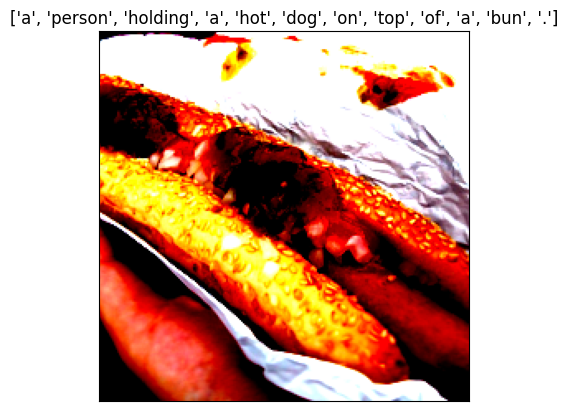

In [21]:
plt.imshow(train_dataset[0][0].permute(1, 2, 0))
plt.title(train_dataset[0][1])
plt.xticks([])
plt.yticks([])
plt.show()

#### Sizes

In [22]:
len(train_dataset), len(val_dataset), len(test_dataset)

(106458, 5000, 11829)

#### Encoder

In [23]:
class Encoder(nn.Module):
    def __init__(self, embedding_size):
        super(Encoder, self).__init__()

        resnet = torchvision.models.resnet18(weights='DEFAULT')
        modules = list(resnet.children())[:-1]
        self.resnet = nn.Sequential(*modules)
        self.fc = nn.Linear(resnet.fc.in_features, embedding_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

        self.fine_tune()

    def forward(self, images):
        features = self.resnet(images)
        features = features.view(features.size(0), -1)
        features = self.fc(features)
        features = self.relu(features)
        features = self.dropout(features)
        return features

    def fine_tune(self):
        for p in self.resnet.parameters():
            p.requires_grad = True

        for p in self.fc.parameters():
            p.requires_grad = True

#### Decoder

In [24]:
class Decoder(nn.Module):
  def __init__(self, embedding_size, vocab_size, hidden_size, num_layers):
    super(Decoder, self).__init__()
    self.embedding = nn.Embedding(vocab_size, embedding_size)
    self.lstm = nn.LSTM(embedding_size, hidden_size, num_layers, batch_first=True)
    self.fc = nn.Linear(hidden_size, vocab_size)

  def forward(self, input, hidden, cell):
    embeddings = self.embedding(input)

    output, (hidden, cell) = self.lstm(embeddings, (hidden, cell))

    output = self.fc(output.squeeze(1))

    return output, (hidden, cell)

#### Encoder-Decoder

In [25]:
class EncoderDecoder(nn.Module):
  def __init__(self, embedding_size, vocab_size, hidden_size, num_layers):
    super(EncoderDecoder, self).__init__()
    self.num_layers = num_layers
    self.hidden_size = hidden_size

    self.init_hidden = nn.Linear(embedding_size, hidden_size)
    self.init_cell = nn.Linear(embedding_size, hidden_size)

    self.encoder = Encoder(embedding_size)
    self.decoder = Decoder(embedding_size, vocab_size, hidden_size, num_layers)

  def forward(self, images, captions, caption_lengths):
    features = self.encoder(images)
    features = features.unsqueeze(1).permute(1, 0, 2)

    hidden = self.init_hidden(features)
    cell = self.init_cell(features)

    input = captions[:, 0].unsqueeze(1)
    batch_size_t = batch_size

    outputs = []

    for t in range(max(caption_lengths)):
      output, (hidden, cell) = self.decoder(input, hidden, cell)
      #print(f'decoder output shape: {output.shape}')

      if output.size(0) < batch_size:
        padding_size = batch_size - output.size(0)
        padding = output.new_full((padding_size, output.size(1)), token_to_idx["<pad>"])  # Pad with pad token index
        output = torch.cat((output, padding), dim=0)

      outputs.append(output.unsqueeze(1))

      teacher_force = random.random() < 0.5
      prediction = output.argmax(1)

      batch_size_t = sum([l > t for l in caption_lengths])
      input = (
        captions[:batch_size_t, t].unsqueeze(1)
        if teacher_force
        else prediction[:batch_size_t].unsqueeze(1)
      )
      hidden = hidden[:, :batch_size_t, :]
      cell = cell[:, :batch_size_t, :]

    outputs = torch.cat(outputs, dim=1)
    #print(f'\t\tmodel outputs shape: {outputs.shape}')
    return outputs

#### DataLoaders

In [26]:
def collate_fn(batch):
    images, captions = list(zip(*batch))

    indexed_captions = [
        [token_to_idx["<sos>"]] +
        [token_to_idx.get(word, token_to_idx["<unk>"]) for word in seq] +
        [token_to_idx["<eos>"]]
        for seq in captions
    ]

    caption_lengths = [len(seq) for seq in indexed_captions]

    combined = list(zip(images, indexed_captions, caption_lengths))
    combined.sort(key=lambda x: x[2], reverse=True)

    images, indexed_captions, _ = zip(*combined)

    max_length = max(caption_lengths)
    padded_captions = [seq + [token_to_idx["<pad>"]] * (max_length - len(seq)) for seq in indexed_captions]

    padded_captions = torch.tensor(padded_captions, dtype=torch.long)
    images = torch.stack(images, dim=0)

    return images, padded_captions, caption_lengths

In [27]:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=collate_fn,
    shuffle=True,
    num_workers=2
)

In [28]:
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=collate_fn,
    shuffle=False,
    num_workers=2
)

#### Training

In [29]:
embedding_size = 256
hidden_size = 256
num_layers = 1
lr = 0.0001
num_epochs = 1000
start_epoch = 0

In [30]:
torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [31]:
model = EncoderDecoder(embedding_size, vocab_size, hidden_size, num_layers).to(device)

In [32]:
# def init_weights(m):
#     if isinstance(m, nn.LSTM):
#         # Apply Xavier initialization to LSTM layers
#         for name, param in m.named_parameters():
#             if 'weight_ih' in name:  # Input-to-hidden weights
#                 nn.init.xavier_uniform_(param.data)  # Xavier uniform
#             elif 'weight_hh' in name:  # Hidden-to-hidden weights
#                 nn.init.xavier_uniform_(param.data)  # Xavier uniform
#             elif 'bias' in name:
#                 nn.init.constant_(param.data, 0)  # Bias initialized to zero

#     elif isinstance(m, nn.Embedding):
#         # Apply Uniform initialization to Embedding layers
#         nn.init.uniform_(m.weight.data, -0.1, 0.1)  # Uniform initialization

#     elif isinstance(m, nn.Linear):
#         # Apply Xavier initialization to Linear layers (if present)
#         nn.init.xavier_uniform_(m.weight.data)
#         if m.bias is not None:
#             nn.init.constant_(m.bias.data, 0)  # Bias initialized to zero

#     elif isinstance(m, nn.Conv2d):
#         # Apply Xavier initialization to Conv2D layers
#         nn.init.kaiming_uniform_(m.weight.data, a=math.sqrt(5))  # Kaiming uniform
#         if m.bias is not None:
#             nn.init.constant_(m.bias.data, 0)  # Bias initialized to zero

# model.apply(init_weights)

In [33]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total number of trainable parameters: {trainable_params}')

Total number of trainable parameters: 16092332


In [34]:
criterion = nn.CrossEntropyLoss(ignore_index=token_to_idx["<pad>"]).cuda()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [35]:
writer = SummaryWriter(log_dir="runs/image_captioning")

patience = 5
best_model_wts = copy.deepcopy(model.state_dict())
best_loss = float("inf")
epochs_since_improvement = 0

In [38]:
from nltk.translate.bleu_score import corpus_bleu

epoch = start_epoch
while epoch <= num_epochs:
  start_time = time.time()

  model.train()
  running_loss = 0.0
  train_samples = 0
  for idx, (images, captions, caption_lengths) in enumerate(train_loader):
    images = images.to(device)
    captions = captions.to(device)

    batch_size = captions.shape[0]

    optimizer.zero_grad()

    outputs = model(images, captions, caption_lengths)

    loss = criterion(outputs[:, 1:, :].reshape(-1, vocab_size), captions[:, 1:].reshape(-1))

    running_loss += loss.item() * batch_size
    train_samples += batch_size

    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
    optimizer.step()

  avg_train_loss = running_loss / train_samples
  writer.add_scalar("Loss/train", avg_train_loss, epoch)

  model.eval()
  val_loss = 0.0
  val_samples = 0
  references = []
  predictions = []
  with torch.no_grad():
    for idx, (images, captions, caption_lengths) in enumerate(val_loader):
      images = images.to(device)
      captions = captions.to(device)

      batch_size = captions.size(0)

      outputs = model(images, captions, caption_lengths)

      loss = criterion(outputs[:, 1:, :].reshape(-1, vocab_size), captions[:, 1:].reshape(-1))

      val_loss += loss.item() * batch_size
      val_samples += batch_size

      pred_captions = outputs.argmax(dim=-1)  # Assuming output is logits over vocab size
      pred_captions = pred_captions.cpu().numpy()

      for i in range(batch_size):
            # Convert tensor captions back to list of words (ignoring <start>, <end> tokens, for example)
            ref = captions[i].cpu().numpy()
            ref_words = [idx_to_token[idx] for idx in ref if idx != token_to_idx[sos_token] and idx != token_to_idx[eos_token] and idx != token_to_idx[pad_token] ]
            references.append([ref_words])

            pred = pred_captions[i]
            pred_words = [idx_to_token[idx] for idx in pred if idx != token_to_idx[sos_token] and idx != token_to_idx[eos_token] and idx != token_to_idx[pad_token]]
            predictions.append(pred_words)

  avg_val_loss = val_loss / val_samples
  writer.add_scalar("Loss/val", avg_val_loss, epoch)

  bleu_score = corpus_bleu(references, predictions)
  writer.add_scalar("BLEU/val", bleu_score, epoch)

  if avg_val_loss < best_loss:
      best_loss = avg_val_loss
      best_model_wts = copy.deepcopy(model.state_dict())
      torch.save({
        'epoch': epoch,
        'model_state_dict': best_model_wts,
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': avg_train_loss,
      }, 'best_model.pth')  # Save the best model
      epochs_since_improvement = 0
  else:
      epochs_since_improvement += 1

  torch.save({
      'epoch': epoch,
      'model_state_dict': model.state_dict(),
      'optimizer_state_dict': optimizer.state_dict(),
      'loss': avg_train_loss,
  }, f"checkpoint_epoch_{epoch}.pth")

  # Early stopping condition
  if epochs_since_improvement >= patience:
    print(f"Early stopping at epoch {epoch}")
    break

  epoch_time = time.time() - start_time
  print(f"Epoch {epoch}/{num_epochs - 1}, "
        f"Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, BLEU Score: {bleu_score:.4f} "
        f"Time: {epoch_time:.2f}s")

  epoch += 1

model.load_state_dict(best_model_wts)

writer.close()

checkpoint = torch.load(f'checkpoint_epoch_{epoch}.pth')
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
start_epoch = checkpoint['epoch'] + 1
epochs_since_improvement = 0

Epoch 48/999, Train Loss: 3.0604, Val Loss: 3.2965, BLEU Score: 0.0436 Time: 179.01s
Epoch 49/999, Train Loss: 3.0596, Val Loss: 3.3316, BLEU Score: 0.0396 Time: 179.52s
Epoch 50/999, Train Loss: 3.0569, Val Loss: 3.3170, BLEU Score: 0.0430 Time: 179.54s
Epoch 51/999, Train Loss: 3.0440, Val Loss: 3.2283, BLEU Score: 0.0461 Time: 179.39s
Early stopping at epoch 52


/tmp/ipykernel_3221755/657560431.py:106: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(f'checkpoint_epoch_{epoch}.pth')
